In [31]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scipy cvxpy plotly openpyxl riskfolio-lib streamlit


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
pip install --upgrade curl_cffi yfinance


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
import cvxpy as cp
import warnings
warnings.filterwarnings("ignore")

RF = 0.065   # India 91-day T-bill ~6.5%


In [34]:
# │ CELL 2 — Fetch & Align Data                                             │
# │                                                                         │
# │ THE ORDERING FIX:                                                       │
# │ yfinance always returns columns in alphabetical order regardless of     │
# │ what order you pass tickers in. If we don't reorder, mean_returns[i]   │
# │ and w[i] refer to different stocks → wrong return/risk/sharpe.         │
# │                                                                         │
# │ Solution: sort tickers alphabetically ourselves upfront, so our order  │
# │ always matches yfinance's output. One source of truth, no reindexing   │
# │ surprises downstream.                                                   │
# └─────────────────────────────────────────────────────────────────────────┘
 
TICKERS_RAW = [
    "RELIANCE.NS", "TCS.NS",        "HDFCBANK.NS",  "INFY.NS",     "ICICIBANK.NS",
    "HINDUNILVR.NS","SBIN.NS",      "BHARTIARTL.NS","ITC.NS",      "KOTAKBANK.NS",
    "LT.NS",        "AXISBANK.NS",  "ASIANPAINT.NS","MARUTI.NS",   "TITAN.NS",
]
 
prices = yf.download(TICKERS_RAW, period="3y", auto_adjust=True, progress=False)["Close"]
prices = prices.dropna()
 
# Sort alphabetically — keeps alignment consistent across all cells
tickers = sorted([t for t in TICKERS_RAW if t in prices.columns])
prices  = prices[tickers]
short   = [t.replace(".NS", "") for t in tickers]
 
print(f"✓ {prices.shape[1]} tickers × {prices.shape[0]} trading days")
print(f"  Order: {short}")
prices.tail()

✓ 15 tickers × 742 trading days
  Order: ['ASIANPAINT', 'AXISBANK', 'BHARTIARTL', 'HDFCBANK', 'HINDUNILVR', 'ICICIBANK', 'INFY', 'ITC', 'KOTAKBANK', 'LT', 'MARUTI', 'RELIANCE', 'SBIN', 'TCS', 'TITAN']


Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,
2026-06-05,2686.699951,1272.300049,1798.199951,747.049988,2121.500000,1262.099976,1172.135742,280.700012,377.450012,3953.199951,13050.0,1291.000000,977.700012,2198.899902,4260.200195
2026-06-08,2659.199951,1268.099976,1813.300049,738.650024,2110.100098,1250.199951,1162.445312,279.450012,377.100006,3875.500000,12912.0,1263.300049,981.950012,2151.399902,4192.399902
2026-06-09,2708.100098,1292.400024,1799.000000,738.349976,2132.800049,1275.000000,1155.300049,280.000000,381.700012,3900.600098,13120.0,1269.199951,1002.700012,2151.000000,4104.899902
2026-06-10,2715.100098,1314.500000,1775.199951,746.849976,2169.500000,1293.300049,1145.300049,283.649994,388.100006,3917.500000,13073.0,1258.800049,1003.250000,2153.899902,4042.100098
2026-06-11,2690.899902,1317.300049,1782.599976,744.599976,2139.800049,1317.000000,1114.599976,282.399994,393.350006,3862.000000,13098.0,1263.000000,1000.700012,2135.600098,4025.199951


In [35]:
# │ CELL 3 — Returns + Volatility                                           │
# └─────────────────────────────────────────────────────────────────────────┘
 
#  Cov matrix is used in portfolio risk formula.                          
#  Corr matrix is easier to read visually. 

returns      = np.log(prices / prices.shift(1)).dropna()
mean_returns = returns.mean() * 252          # annualised, Series indexed by tickers
volatility   = returns.std()  * np.sqrt(252) # annualised
cov_matrix   = returns.cov()  * 252          # annualised
 
n      = len(tickers)
mu     = mean_returns.values   # np array, same order as tickers/prices
Sigma  = cov_matrix.values     # np array, same order
 
# Quick sanity: confirm index alignment
assert list(mean_returns.index) == tickers, "mean_returns index mismatch!"
assert list(cov_matrix.index)   == tickers, "cov_matrix index mismatch!"
print("✓ mean_returns, cov_matrix, tickers all aligned")
print(mean_returns.sort_values(ascending=False))

✓ mean_returns, cov_matrix, tickers all aligned
Ticker
BHARTIARTL.NS    0.263647
SBIN.NS          0.204774
LT.NS            0.183373
ICICIBANK.NS     0.124472
TITAN.NS         0.120338
MARUTI.NS        0.117465
AXISBANK.NS      0.103510
RELIANCE.NS      0.038207
KOTAKBANK.NS     0.016485
HDFCBANK.NS     -0.015397
INFY.NS         -0.018055
ASIANPAINT.NS   -0.050265
HINDUNILVR.NS   -0.053180
ITC.NS          -0.096500
TCS.NS          -0.109419
dtype: float64


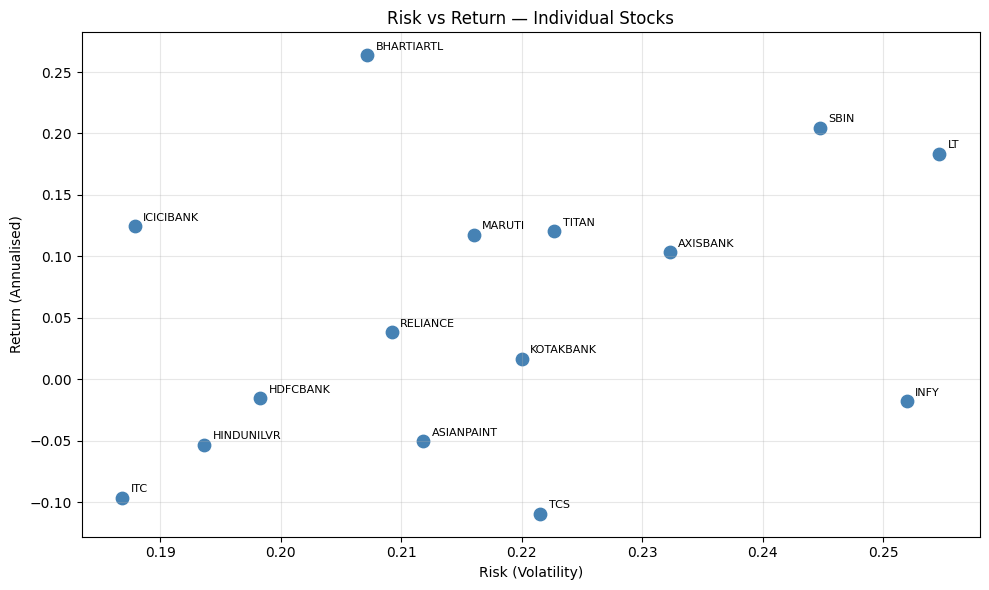

In [36]:
# cell 4 :risk vs return plot

risk_return = pd.DataFrame({"Return": mean_returns, "Risk": volatility})
 
plt.figure(figsize=(10, 6))
plt.scatter(risk_return["Risk"], risk_return["Return"], color="steelblue", s=80)
for stock in risk_return.index:
    plt.annotate(
        stock.replace(".NS", ""),
        (risk_return.loc[stock, "Risk"], risk_return.loc[stock, "Return"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8
    )
plt.xlabel("Risk (Volatility)"); plt.ylabel("Return (Annualised)")
plt.title("Risk vs Return — Individual Stocks")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

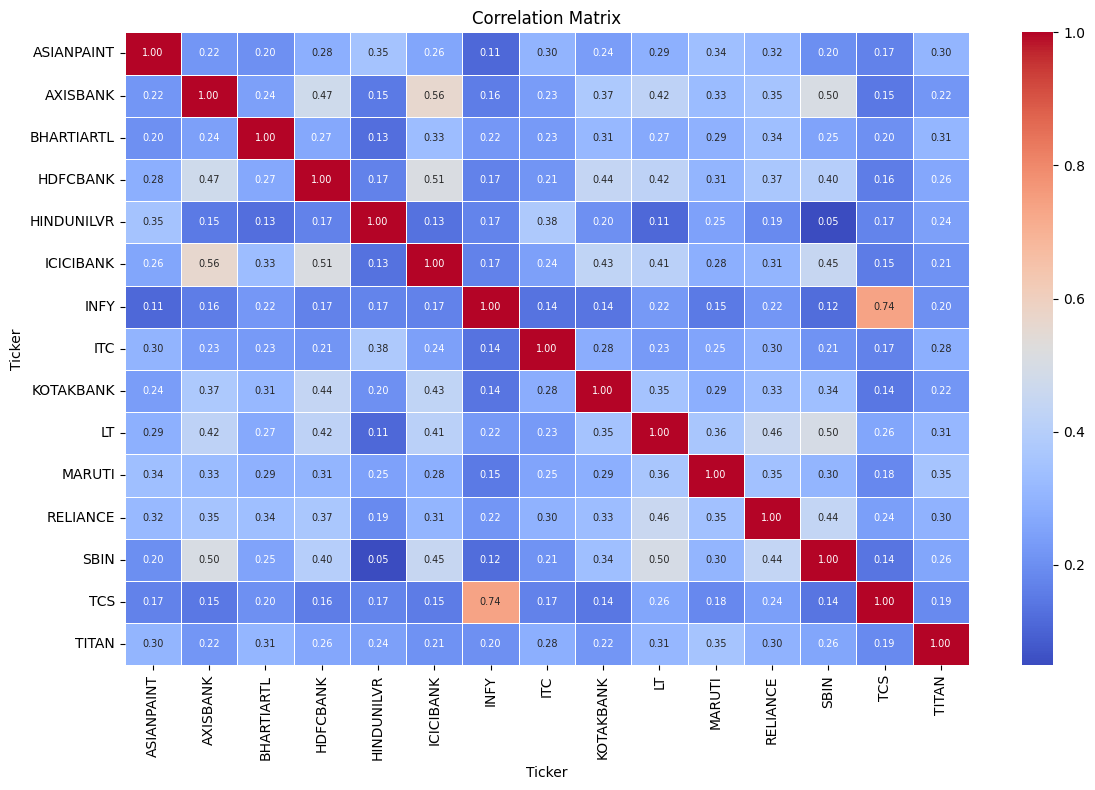

In [37]:
 
plt.figure(figsize=(12, 8))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7},
            xticklabels=short, yticklabels=short)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

In [38]:
# Monte Carlo Simulation                                        
# Randomly generate 1000k weight combinations.                            
# For each: compute portfolio return, risk, sharpe.                       
             
N = 1000000
mc_ret  = np.zeros(N)
mc_risk = np.zeros(N)
mc_shr  = np.zeros(N)
mc_w    = np.zeros((N, n))
 
for i in range(N):
    w          = np.random.dirichlet(np.ones(n))
    mc_ret[i]  = w @ mu
    mc_risk[i] = np.sqrt(w @ Sigma @ w)
    mc_shr[i]  = (mc_ret[i] - RF) / mc_risk[i]
    mc_w[i]    = w
 
mc_df = pd.DataFrame({"Return": mc_ret, "Risk": mc_risk, "Sharpe": mc_shr})
print(f"MC Max Sharpe : {mc_shr.max():.4f}")
print(f"MC Min Risk   : {mc_risk.min()*100:.2f}%")

MC Max Sharpe : 0.8797
MC Min Risk   : 11.68%


In [39]:
# │ CELL 7 — Efficient Frontier (smooth)                                    │
# │ Instead of connecting noisy bin-max points, we smooth the upper        │
# │ envelope so the line looks clean.                                       │
# └─────────────────────────────────────────────────────────────────────────┘
 
mc_df["risk_bin"] = pd.cut(mc_df["Risk"], bins=80)
ef_df = mc_df.loc[mc_df.groupby("risk_bin", observed=True)["Return"].idxmax()].dropna()
ef_df = ef_df.sort_values("Risk")
 
# Smooth with rolling average so the line isn't jagged
ef_df["Return_smooth"] = ef_df["Return"].rolling(window=5, center=True, min_periods=1).mean()
 
 

In [40]:
#  MC best portfolios Max Sharpe & Min Variance Portfolios       
ms_idx = mc_shr.argmax()
mv_idx = mc_risk.argmin()
 
w_mc_sharpe = mc_w[ms_idx]
w_mc_minvar = mc_w[mv_idx]
 
print(f"MC Max Sharpe → Return: {mc_ret[ms_idx]*100:.2f}%  Risk: {mc_risk[ms_idx]*100:.2f}%  Sharpe: {mc_shr[ms_idx]:.4f}")
print(f"MC Min Var    → Return: {mc_ret[mv_idx]*100:.2f}%  Risk: {mc_risk[mv_idx]*100:.2f}%  Sharpe: {mc_shr[mv_idx]:.4f}")

MC Max Sharpe → Return: 20.30%  Risk: 15.68%  Sharpe: 0.8797
MC Min Var    → Return: 0.69%  Risk: 11.68%  Sharpe: -0.4974


In [41]:
# │ CELL 9 — Helper: metrics function + shared excess return vector        │
# └─────────────────────────────────────────────────────────────────────────┘
 
from scipy.optimize import minimize as sp_minimize
 
exc = mu - RF     # excess return vector, used in all cases
 
def port_metrics(w, label):
    """Return, Risk, Sharpe, HHI for a weight vector."""
    r   = w @ mu
    ri  = np.sqrt(w @ Sigma @ w)
    s   = (r - RF) / ri
    hhi = np.sum(w**2)   # 1/n = max diversified, 1.0 = fully concentrated
    return {"Case": label, "Return %": round(r*100,2), "Risk %": round(ri*100,2),
            "Sharpe": round(s,4), "HHI": round(hhi,4)}
 
def sharpe_qp(extra_constraints=None):
    """
    Maximise Sharpe via change-of-variables:
      y = w / (w'μ - rf)
      min  y'Σy   s.t.  (μ-rf)'y = 1,  y >= 0  [+ extra constraints on y]
      w* = y / sum(y)
    extra_constraints: list of cvxpy constraints referencing variable y
    """
    y    = cp.Variable(n)
    base = [exc @ y == 1, y >= 0]
    cons = base + (extra_constraints(y) if extra_constraints else [])
    cp.Problem(cp.Minimize(cp.quad_form(y, Sigma)), cons).solve(solver=cp.CLARABEL)
    return y.value / y.value.sum()
 
results = []

In [42]:
# │ CELL 9a — Case 1: Unconstrained Max Sharpe                              │
# │ Pure Markowitz — no constraints beyond w>=0, sum=1.                   │
# │ Typically concentrates into 2-3 best risk-adjusted stocks.             │
# └─────────────────────────────────────────────────────────────────────────┘
 
w1 = sharpe_qp()
results.append(port_metrics(w1, "Case 1 — Unconstrained"))
print(pd.Series(w1, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w1, "Case 1"))
 

BHARTIARTL    0.7214
SBIN          0.2264
LT            0.0521
TITAN         0.0000
MARUTI        0.0000
ICICIBANK     0.0000
AXISBANK      0.0000
RELIANCE      0.0000
KOTAKBANK     0.0000
INFY          0.0000
HDFCBANK      0.0000
HINDUNILVR    0.0000
ASIANPAINT    0.0000
ITC           0.0000
TCS           0.0000
dtype: float64
{'Case': 'Case 1', 'Return %': np.float64(24.61), 'Risk %': np.float64(17.75), 'Sharpe': np.float64(1.0202), 'HHI': np.float64(0.5745)}


In [43]:
# │ CELL 9b — Case 2: Max 30% per stock                                     │
# │ Diversified mutual fund mandate.                                        │
# │ In y-space: w_i <= 0.30 translates to y_i <= 0.30 * sum(y)            │
# │ because w_i = y_i / sum(y).  This is linear → DCP-compliant.          │
# └─────────────────────────────────────────────────────────────────────────┘
 
w2 = sharpe_qp(lambda y: [y <= 0.30 * cp.sum(y)])
results.append(port_metrics(w2, "Case 2 — Max 30% cap"))
print(pd.Series(w2, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w2, "Case 2"))

SBIN          0.3000
BHARTIARTL    0.3000
LT            0.1729
ICICIBANK     0.0976
TITAN         0.0849
MARUTI        0.0446
AXISBANK      0.0000
RELIANCE      0.0000
HINDUNILVR    0.0000
KOTAKBANK     0.0000
INFY          0.0000
HDFCBANK      0.0000
ASIANPAINT    0.0000
ITC           0.0000
TCS           0.0000
dtype: float64
{'Case': 'Case 2', 'Return %': np.float64(19.98), 'Risk %': np.float64(15.81), 'Sharpe': np.float64(0.853), 'HHI': np.float64(0.2286)}


In [44]:
# │ CELL 9c — Case 3: Max 20% per stock                                     │
# │ Conservative diversification — forces at least 5 stocks to be active. │
# └─────────────────────────────────────────────────────────────────────────┘
 
w3 = sharpe_qp(lambda y: [y <= 0.20 * cp.sum(y)])
results.append(port_metrics(w3, "Case 3 — Max 20% cap"))
print(pd.Series(w3, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w3, "Case 3"))

BHARTIARTL    0.2000
SBIN          0.2000
LT            0.2000
ICICIBANK     0.1905
TITAN         0.1280
MARUTI        0.0815
AXISBANK      0.0000
RELIANCE      0.0000
KOTAKBANK     0.0000
INFY          0.0000
HINDUNILVR    0.0000
HDFCBANK      0.0000
ASIANPAINT    0.0000
ITC           0.0000
TCS           0.0000
dtype: float64
{'Case': 'Case 3', 'Return %': np.float64(17.9), 'Risk %': np.float64(15.12), 'Sharpe': np.float64(0.7541), 'HHI': np.float64(0.1793)}


In [45]:
# │ CELL 9d — Case 4: Sector cap 40%                                        │
# │ No single sector can exceed 40% of the portfolio.                      │
# │ Finance sector (5 stocks) is the binding constraint here.              │
# └─────────────────────────────────────────────────────────────────────────┘
 
# Sectors mapped to alphabetically-sorted tickers
SECTORS = {
    "Finance":   ["AXISBANK.NS","HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","SBIN.NS"],
    "IT":        ["INFY.NS","TCS.NS"],
    "Consumer":  ["ASIANPAINT.NS","HINDUNILVR.NS","ITC.NS","TITAN.NS"],
    "Auto":      ["MARUTI.NS"],
    "Energy":    ["RELIANCE.NS"],
    "Telecom":   ["BHARTIARTL.NS"],
    "Industrial":["LT.NS"],
}
 
def sector_constraints(y):
    cons = []
    for members in SECTORS.values():
        idx = [tickers.index(t) for t in members if t in tickers]
        if idx:
            cons.append(cp.sum(y[idx]) <= 0.40 * cp.sum(y))
    return cons
 
w4 = sharpe_qp(sector_constraints)
results.append(port_metrics(w4, "Case 4 — Sector 40% cap"))
print(pd.Series(w4, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w4, "Case 4"))
 

BHARTIARTL    0.4000
SBIN          0.3287
LT            0.1449
TITAN         0.0559
ICICIBANK     0.0478
MARUTI        0.0227
AXISBANK      0.0000
RELIANCE      0.0000
KOTAKBANK     0.0000
INFY          0.0000
HINDUNILVR    0.0000
HDFCBANK      0.0000
ASIANPAINT    0.0000
TCS           0.0000
ITC           0.0000
dtype: float64
{'Case': 'Case 4', 'Return %': np.float64(21.47), 'Risk %': np.float64(16.27), 'Sharpe': np.float64(0.9202), 'HHI': np.float64(0.295)}


In [46]:
# │ CELL 9e — Case 5: Target Return 15% + Min Risk                          │
# │ Pension / endowment style: hit a return target, minimise risk.         │
# │ Standard QP — no change-of-variables needed.                           │
# └─────────────────────────────────────────────────────────────────────────┘
 
TARGET = 0.15
w5_var = cp.Variable(n)
cp.Problem(cp.Minimize(cp.quad_form(w5_var, Sigma)),
           [cp.sum(w5_var)==1, w5_var>=0, mu @ w5_var >= TARGET]).solve(solver=cp.CLARABEL)
w5 = w5_var.value
results.append(port_metrics(w5, "Case 5 — Target 15% + Min Risk"))
print(pd.Series(w5, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w5, "Case 5"))
 

BHARTIARTL    0.3131
ICICIBANK     0.1868
HINDUNILVR    0.1351
SBIN          0.1192
TITAN         0.0947
MARUTI        0.0874
LT            0.0322
INFY          0.0316
AXISBANK      0.0000
RELIANCE      0.0000
ASIANPAINT    0.0000
TCS           0.0000
ITC           0.0000
KOTAKBANK     0.0000
HDFCBANK      0.0000
dtype: float64
{'Case': 'Case 5', 'Return %': np.float64(15.0), 'Risk %': np.float64(13.16), 'Sharpe': np.float64(0.6459), 'HHI': np.float64(0.184)}


In [47]:
# │ CELL 9f — Case 6: Risk Parity (Equal Risk Contribution)                 │
# │ Each asset contributes equally to total portfolio variance:            │
# │   RC_i = w_i * (Σw)_i  = total_variance / n  for all i               │
# │ Not a QP → solved with scipy SLSQP.                                   │
# │ HHI will be closest to 1/n = most diversified of all 6 cases.         │
# └─────────────────────────────────────────────────────────────────────────┘
 
def risk_parity_obj(w):
    pv = w @ Sigma @ w
    rc = w * (Sigma @ w)                  # risk contribution per asset
    return np.sum((rc - pv / n) ** 2)     # minimise spread of RC
 
res = sp_minimize(
    risk_parity_obj,
    x0     = np.ones(n) / n,
    method = "SLSQP",
    bounds = [(0, None)] * n,
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
    options = {"ftol": 1e-12, "maxiter": 1000}
)
w6 = res.x / res.x.sum()
results.append(port_metrics(w6, "Case 6 — Risk Parity"))
print(pd.Series(w6, index=short).sort_values(ascending=False).round(4))
print(port_metrics(w6, "Case 6"))
print(f"  HHI benchmark (1/n): {1/n:.4f}")

HINDUNILVR    0.0895
ITC           0.0812
TCS           0.0725
BHARTIARTL    0.0720
ASIANPAINT    0.0701
ICICIBANK     0.0692
INFY          0.0656
HDFCBANK      0.0654
TITAN         0.0654
MARUTI        0.0634
KOTAKBANK     0.0624
RELIANCE      0.0609
AXISBANK      0.0567
SBIN          0.0565
LT            0.0492
dtype: float64
{'Case': 'Case 6', 'Return %': np.float64(4.65), 'Risk %': np.float64(12.09), 'Sharpe': np.float64(-0.1531), 'HHI': np.float64(0.0681)}
  HHI benchmark (1/n): 0.0667


In [48]:
# │ CELL 9g — Summary: All 6 Cases                                          │
# └─────────────────────────────────────────────────────────────────────────┘
 
df_results = pd.DataFrame(results)
print("\n" + "="*70)
print(f"  HHI: 1/n benchmark = {round(1/n,4)}  (lower = more diversified)")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)


  HHI: 1/n benchmark = 0.0667  (lower = more diversified)
                          Case  Return %  Risk %  Sharpe    HHI
        Case 1 — Unconstrained     24.61   17.75  1.0202 0.5745
          Case 2 — Max 30% cap     19.98   15.81  0.8530 0.2286
          Case 3 — Max 20% cap     17.90   15.12  0.7541 0.1793
       Case 4 — Sector 40% cap     21.47   16.27  0.9202 0.2950
Case 5 — Target 15% + Min Risk     15.00   13.16  0.6459 0.1840
          Case 6 — Risk Parity      4.65   12.09 -0.1531 0.0681


In [49]:
# │ CELL 9h — CVXPY Exact Efficient Frontier                                │
# │                                                                         │
# │ Solve min w'Σw s.t. μ'w = r_target, Σw=1, w≥0                        │
# │ for 50 target returns from min-achievable to max-achievable.           │
# │ Each solve gives one point on the TRUE frontier.                       │
# └─────────────────────────────────────────────────────────────────────────┘
 
# Find feasible return range: min = min(μ), max = max(μ)
r_min = mu.min() + 0.001          # slightly above lowest single-stock return
r_max = mu.max() - 0.001          # slightly below highest single-stock return
target_returns = np.linspace(r_min, r_max, 50)
 
ef_risks   = []
ef_returns = []
 
for r_target in target_returns:
    w_ef = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w_ef, Sigma)),
        [mu @ w_ef == r_target, cp.sum(w_ef) == 1, w_ef >= 0]
    )
    prob.solve(solver=cp.CLARABEL)
    if prob.status in ("optimal", "optimal_inaccurate") and w_ef.value is not None:
        ef_risks.append(np.sqrt(w_ef.value @ Sigma @ w_ef.value))
        ef_returns.append(r_target)
 
ef_risks    = np.array(ef_risks)
ef_returns  = np.array(ef_returns)
print(f"✓ Solved {len(ef_risks)}/50 frontier points")
 

✓ Solved 50/50 frontier points


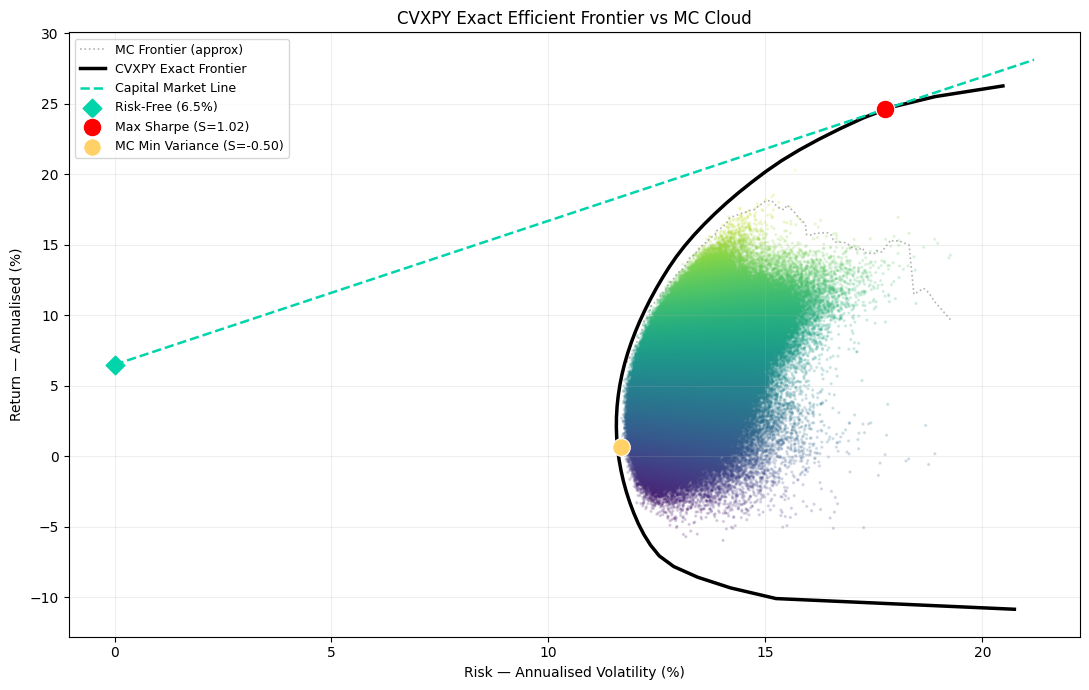

In [50]:
# │ CELL 9i — Plot: MC Cloud + CVXPY Exact Frontier + CML                  │
# └─────────────────────────────────────────────────────────────────────────┘

frontier = pd.DataFrame({
    "Risk": ef_risks,
    "Return": ef_returns
})

frontier = frontier.sort_values("Risk")

efficient = []
max_ret = -np.inf

for _, row in frontier.iterrows():
    if row["Return"] > max_ret:
        efficient.append(row)
        max_ret = row["Return"]

frontier = pd.DataFrame(efficient)
 
# CVXPY Max Sharpe metrics (w1 from Case 1)
ret_cvx    = w1 @ mu
risk_cvx   = np.sqrt(w1 @ Sigma @ w1)
sharpe_cvx = (ret_cvx - RF) / risk_cvx
 
# CML from RF through exact tangency point
x_cml = np.linspace(0, mc_risk.max() * 1.1, 300)
y_cml = RF + sharpe_cvx * x_cml
 
fig, ax = plt.subplots(figsize=(11, 7))
 
# MC cloud in background
ax.scatter(mc_risk*100, mc_ret*100, c=mc_shr, cmap="viridis",
           alpha=0.15, s=2, zorder=1, label="_nolegend_")
 
# MC smoothed frontier (faint, for comparison)
ax.plot(ef_df["Risk"]*100, ef_df["Return_smooth"]*100,
        color="gray", lw=1.2, linestyle=":", alpha=0.6, label="MC Frontier (approx)")
 
# CVXPY exact frontier
ax.plot(ef_risks*100, ef_returns*100,
        color="black", lw=2.5, zorder=4, label="CVXPY Exact Frontier")
 
# CML
ax.plot(x_cml*100, y_cml*100,
        color="#00d4aa", lw=1.8, linestyle="--", zorder=4, label="Capital Market Line")
 
# Key points
ax.scatter(0, RF*100,
           color="#00d4aa", s=90, zorder=6, marker="D",
           label=f"Risk-Free ({RF*100:.1f}%)")
ax.scatter(risk_cvx*100, ret_cvx*100,
           color="red", s=180, zorder=6, edgecolors="white", lw=0.8,
           label=f"Max Sharpe (S={sharpe_cvx:.2f})")
ax.scatter(mc_risk[mv_idx]*100, mc_ret[mv_idx]*100,
           color="#ffd166", s=160, zorder=6, edgecolors="white", lw=0.8,
           label=f"MC Min Variance (S={mc_shr[mv_idx]:.2f})")
 
ax.set_xlabel("Risk — Annualised Volatility (%)")
ax.set_ylabel("Return — Annualised (%)")
ax.set_title("CVXPY Exact Efficient Frontier vs MC Cloud")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [51]:
# │ CELL 10 — VaR & CVaR  (on Case 1 Max Sharpe)                           │
# └─────────────────────────────────────────────────────────────────────────┘
 
port_daily = returns.values @ w1
 
hist_var   = -np.percentile(port_daily, 5)
hist_cvar  = -port_daily[port_daily <= -hist_var].mean()
mu_d, s_d  = port_daily.mean(), port_daily.std()
param_var  = -(mu_d + norm.ppf(0.05) * s_d)
param_cvar = -(mu_d - s_d * norm.pdf(norm.ppf(0.05)) / 0.05)
 
print("── VaR / CVaR — Unconstrained Max Sharpe ──")
print(f"  Historical VaR  (95%): {hist_var*100:.3f}%")
print(f"  Historical CVaR (95%): {hist_cvar*100:.3f}%")
print(f"  Parametric VaR  (95%): {param_var*100:.3f}%")
print(f"  Parametric CVaR (95%): {param_cvar*100:.3f}%")

── VaR / CVaR — Unconstrained Max Sharpe ──
  Historical VaR  (95%): 1.559%
  Historical CVaR (95%): 2.436%
  Parametric VaR  (95%): 1.741%
  Parametric CVaR (95%): 2.208%


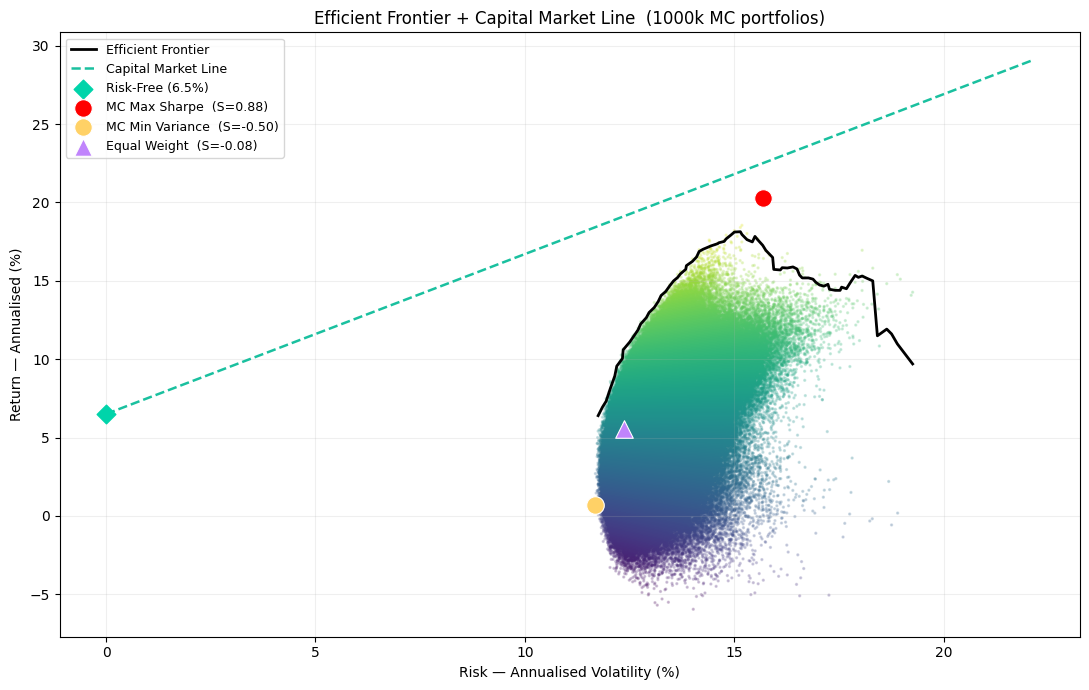

In [52]:
# │ CELL 11 — Efficient Frontier Plot (clean, simple)                       │
# │ Max Sharpe plotted using ONLY MC result so it stays inside the cloud.  │
# │ CVXPY point shown separately — may be outside cloud (correct: it's     │
# │ the exact optimum MC sampling didn't reach).                           │
# └─────────────────────────────────────────────────────────────────────────┘
 
# Equal weight
w_eq      = np.ones(n) / n
ret_eq    = w_eq @ mu;  risk_eq = np.sqrt(w_eq @ Sigma @ w_eq)
sharpe_eq = (ret_eq - RF) / risk_eq
 
# CVXPY case 1 metrics
ret_cvx   = w1 @ mu;    risk_cvx  = np.sqrt(w1 @ Sigma @ w1)
sharpe_cvx = (ret_cvx - RF) / risk_cvx
 
# CML
x_cml = np.linspace(0, mc_risk.max() * 1.15, 300)
y_cml = RF + sharpe_cvx * x_cml
 
fig, ax = plt.subplots(figsize=(11, 7))
 
# Cloud
ax.scatter(mc_risk*100, mc_ret*100, c=mc_shr, cmap="viridis",
           alpha=0.2, s=2, zorder=1)
 
# Smooth EF line
ax.plot(ef_df["Risk"]*100, ef_df["Return_smooth"]*100,
        color="black", lw=2, label="Efficient Frontier", zorder=3)
 
# CML
ax.plot(x_cml*100, y_cml*100,
        color="#1ac09f", lw=1.8, linestyle="--", label="Capital Market Line", zorder=3)
 
# Key points
ax.scatter(0, RF*100, color="#00d4aa", s=90, zorder=5, marker="D",
           label=f"Risk-Free ({RF*100:.1f}%)")
ax.scatter(mc_risk[ms_idx]*100, mc_ret[ms_idx]*100, color="red",
           s=160, zorder=5, edgecolors="white", lw=0.8,
           label=f"MC Max Sharpe  (S={mc_shr[ms_idx]:.2f})")
ax.scatter(mc_risk[mv_idx]*100, mc_ret[mv_idx]*100, color="#ffd166",
           s=160, zorder=5, edgecolors="white", lw=0.8,
           label=f"MC Min Variance  (S={mc_shr[mv_idx]:.2f})")
ax.scatter(risk_eq*100, ret_eq*100, color="#c084fc",
           s=160, zorder=5, edgecolors="white", lw=0.8, marker="^",
           label=f"Equal Weight  (S={sharpe_eq:.2f})")
 
ax.set_xlabel("Risk — Annualised Volatility (%)")
ax.set_ylabel("Return — Annualised (%)")
ax.set_title("Efficient Frontier + Capital Market Line  (1000k MC portfolios)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

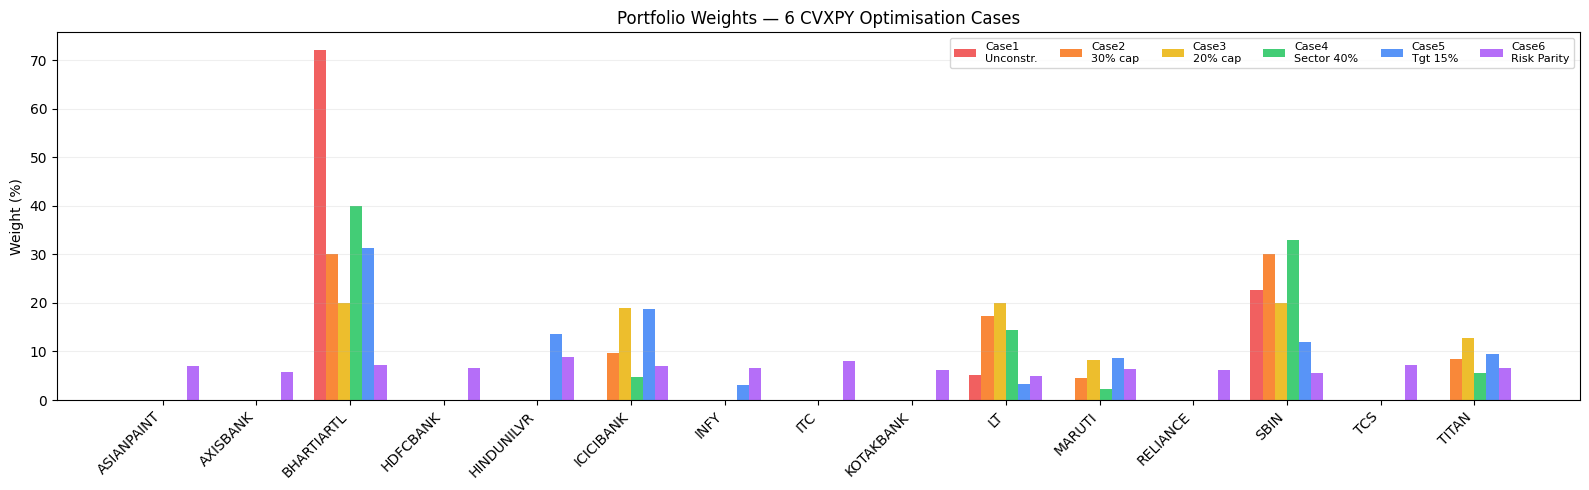

In [53]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 12 — 6 CVXPY Cases: Weight Bar Chart                              │
# └─────────────────────────────────────────────────────────────────────────┘
 
cases   = [w1, w2, w3, w4, w5, w6]
clabels = ["Case1\nUnconstr.", "Case2\n30% cap", "Case3\n20% cap",
           "Case4\nSector 40%", "Case5\nTgt 15%", "Case6\nRisk Parity"]
colors  = ["#ef4444","#f97316","#eab308","#22c55e","#3b82f6","#a855f7"]
 
x  = np.arange(n)
bw = 0.13
fig, ax = plt.subplots(figsize=(16, 5))
for i, (w_i, lbl, col) in enumerate(zip(cases, clabels, colors)):
    ax.bar(x + (i - 2.5)*bw, w_i*100, width=bw, color=col, alpha=0.85, label=lbl)
 
ax.set_xticks(x); ax.set_xticklabels(short, rotation=45, ha="right")
ax.set_ylabel("Weight (%)")
ax.set_title("Portfolio Weights — 6 CVXPY Optimisation Cases")
ax.legend(fontsize=8, ncol=6)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

In [54]:
# │ CELL 14 — Black-Litterman (Intermediate)                               │
# │                                                                         │
# │ Step 1: Market weights (inverse-vol proxy)                             │
# │ Step 2: Implied equilibrium returns  Π = δ·Σ·w_mkt                   │
# │ Step 3: View matrix P, Q, Ω                                           │
# │ Step 4: Posterior μ_BL (Bayesian blend of Π and views)                │
# │ Step 5: Optimise on μ_BL                                              │
# │                                                                         │
# │ To add more views: add rows to P and Q. Nothing else changes.         │
# └─────────────────────────────────────────────────────────────────────────┘
 
# ── Step 1: Market weights ────────────────────────────────────────────────
w_mkt  = 1.0 / volatility.values
w_mkt /= w_mkt.sum()
 
print("── Market Weights (inv-vol proxy) ──")
print(pd.Series(w_mkt, index=short).sort_values(ascending=False).round(4))
 
# ── Step 2: Implied equilibrium returns Π ────────────────────────────────
# Π = δ · Σ · w_mkt  gives the right *shape* but wrong *scale*.
# Raw values come out ~1-3%, far below historical returns of 5-25%.
# Fix: rescale so the market-cap-weighted mean of Π matches historical μ.
# This preserves the relative ordering while keeping returns sensible.
delta = 2.5
tau   = 0.05     # uncertainty in prior; small = trust prior more
 
Pi_raw    = delta * Sigma @ w_mkt
scale     = (w_mkt @ mean_returns.values) / (w_mkt @ Pi_raw)
Pi        = Pi_raw * scale
 
print("\n── Equilibrium Returns Π (rescaled) ──")
print(pd.Series(Pi, index=short).sort_values(ascending=False).round(4))
print(f"  scale factor: {scale:.2f}x  (raw Π was too small by this factor)")
 
# ── Step 3: Views  P · μ = Q ─────────────────────────────────────────────
# View: Banking sector outperforms IT by 5%
#   P row: +1/5 for each banking stock, -1/2 for each IT stock
#   Q    : 0.05
#
# To add a second view, append a row to P and a value to Q — that's it.
 
banking = ["AXISBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "SBIN.NS"]
it      = ["INFY.NS", "TCS.NS"]
 
k  = 1                          # number of views
P  = np.zeros((k, n))
Q  = np.zeros(k)
 
# View 1: Banking beats IT by 5%
for t in banking:
    P[0, tickers.index(t)] = +1.0 / len(banking)
for t in it:
    P[0, tickers.index(t)] = -1.0 / len(it)
Q[0] = 0.05
 
print("── P matrix (non-zero entries) ──")
p_df = pd.Series(P[0], index=short)
print(p_df[p_df != 0].round(4))
print(f"Q = {Q[0]*100:.1f}%  (expected outperformance)")
 
# Ω = diagonal uncertainty matrix
# Standard He-Litterman: Ω = τ · P · Σ · P'
# Each diagonal entry = variance of that view portfolio
Omega = tau * (P @ Sigma @ P.T)     # shape (k, k)
print(f"Ω (view uncertainty) = {Omega[0,0]:.6f}")
 
# ── Step 4: Posterior μ_BL ────────────────────────────────────────────────
# μ_BL = [(τΣ)⁻¹ + P'Ω⁻¹P]⁻¹ · [(τΣ)⁻¹·Π + P'·Ω⁻¹·Q]
#
# Bayesian intuition:
#   - First term  (τΣ)⁻¹·Π  = prior belief (market equilibrium)
#   - Second term P'·Ω⁻¹·Q  = likelihood from your view
#   - Blend weighted by precision (inverse variance) of each
 
tauSigma_inv = np.linalg.inv(tau * Sigma)
Omega_inv    = np.linalg.inv(Omega)
 
M     = tauSigma_inv + P.T @ Omega_inv @ P
mu_bl = np.linalg.inv(M) @ (tauSigma_inv @ Pi + P.T @ Omega_inv @ Q)
 
print("── Historical μ  vs  Equilibrium Π  vs  Posterior μ_BL ──")
compare = pd.DataFrame({
    "Hist μ %":  (mean_returns.values * 100).round(2),
    "Equil Π %": (Pi * 100).round(2),
    "BL μ %":    (mu_bl * 100).round(2),
    "Δ BL-Hist": ((mu_bl - mean_returns.values) * 100).round(2),
}, index=short)
print(compare.sort_values("Δ BL-Hist", ascending=False).to_string())
 
# ── Step 5: Optimise on μ_BL ─────────────────────────────────────────────
exc_bl = mu_bl - RF
 
print(f"\n── exc_bl check (must have at least some positive values) ──")
exc_series = pd.Series(exc_bl, index=short).sort_values(ascending=False)
print(exc_series.round(4))
 
# If all excess returns are negative the change-of-variables QP is infeasible.
# Guard: if fewer than 3 stocks have positive excess return, raise RF floor.
if (exc_bl > 0).sum() < 3:
    print("\nWARNING: too few positive excess returns — check RF or mu_bl values")
 
# Unconstrained
y_bl  = cp.Variable(n)
prob_bl = cp.Problem(cp.Minimize(cp.quad_form(y_bl, Sigma)),
                     [exc_bl @ y_bl == 1, y_bl >= 0])
prob_bl.solve(solver=cp.CLARABEL)
print(f"\nBL unconstrained solver status: {prob_bl.status}")
assert y_bl.value is not None, f"BL solve failed: {prob_bl.status}"
w_bl  = y_bl.value / y_bl.value.sum()
 
# 30% cap
y_bl2   = cp.Variable(n)
prob_bl2 = cp.Problem(cp.Minimize(cp.quad_form(y_bl2, Sigma)),
                      [exc_bl @ y_bl2 == 1, y_bl2 >= 0,
                       y_bl2 <= 0.30 * cp.sum(y_bl2)])
prob_bl2.solve(solver=cp.CLARABEL)
print(f"BL 30% cap solver status:       {prob_bl2.status}")
assert y_bl2.value is not None, f"BL 30% cap solve failed: {prob_bl2.status}"
w_bl2 = y_bl2.value / y_bl2.value.sum()
 
# ── Weight comparison: Markowitz vs BL ───────────────────────────────────
print("── Weight Shift: Markowitz → Black-Litterman ──")
w_compare = pd.DataFrame({
    "Markowitz": np.round(w1 * 100, 1),
    "BL":        np.round(w_bl * 100, 1),
    "Δ":         np.round((w_bl - w1) * 100, 1),
}, index=short).sort_values("Δ", ascending=False)
print(w_compare.to_string())

── Market Weights (inv-vol proxy) ──
ITC           0.0768
ICICIBANK     0.0764
HINDUNILVR    0.0741
HDFCBANK      0.0724
BHARTIARTL    0.0693
RELIANCE      0.0686
ASIANPAINT    0.0678
MARUTI        0.0664
KOTAKBANK     0.0652
TCS           0.0648
TITAN         0.0644
AXISBANK      0.0618
SBIN          0.0586
INFY          0.0570
LT            0.0564
dtype: float64

── Equilibrium Returns Π (rescaled) ──
LT            0.0711
SBIN          0.0627
AXISBANK      0.0622
RELIANCE      0.0570
KOTAKBANK     0.0555
MARUTI        0.0540
HDFCBANK      0.0536
TITAN         0.0515
ICICIBANK     0.0508
INFY          0.0491
ASIANPAINT    0.0482
BHARTIARTL    0.0472
TCS           0.0448
ITC           0.0414
HINDUNILVR    0.0355
dtype: float64
  scale factor: 1.39x  (raw Π was too small by this factor)
── P matrix (non-zero entries) ──
AXISBANK     0.2
HDFCBANK     0.2
ICICIBANK    0.2
INFY        -0.5
KOTAKBANK    0.2
SBIN         0.2
TCS         -0.5
dtype: float64
Q = 5.0%  (expected outperformance)

In [55]:
# │ CELL 15 — Final Comparison Table                                        │
# └─────────────────────────────────────────────────────────────────────────┘
 
portfolios = {
    "Markowitz (Unconstrained)": w1,
    "Markowitz 30% cap":         w2,
    "Markowitz 20% cap":         w3,
    "Sector 40% cap":            w4,
    "Target Return 15%":         w5,
    "Risk Parity":               w6,
    "Black-Litterman":           w_bl,
    "BL + 30% cap":              w_bl2,
}
 
def metrics_row(label, w):
    r  = w @ mu
    ri = np.sqrt(w @ Sigma @ w)
    return {"Method":   label,
            "Return %": round(r*100, 1),
            "Risk %":   round(ri*100, 1),
            "Sharpe":   round((r - RF) / ri, 2),
            "HHI":      round(np.sum(w**2), 2)}
 
rows        = [metrics_row(label, w) for label, w in portfolios.items()]
final_table = pd.DataFrame(rows)
 
# ── Part A: Metrics table ─────────────────────────────────────────────────
print("\n" + "="*62)
print(f"  {'Method':<28} {'Return':>7}  {'Risk':>5}  {'Sharpe':>6}  {'HHI':>4}")
print("-"*62)
for _, r in final_table.iterrows():
    print(f"  {r['Method']:<28} {r['Return %']:>6.1f}%  {r['Risk %']:>4.1f}%  {r['Sharpe']:>6.2f}  {r['HHI']:>4.2f}")
print("="*62)
print(f"  HHI ref: Equal Weight={round(np.sum(w_eq**2),2)}  |  1/n={round(1/n,2)}  (lower = more diversified)")
print("="*62)
 
# ── Part B: Weight allocation per portfolio ───────────────────────────────
w_matrix = pd.DataFrame(
    {label: np.round(w * 100, 1) for label, w in portfolios.items()},
    index=short
)
# Drop stocks with zero weight across all portfolios to keep it readable
w_matrix = w_matrix.loc[(w_matrix > 0.1).any(axis=1)]
 
print("\n── Weight Allocation (%) per Portfolio ──")
print(w_matrix.to_string())
print(f"\n  Rows shown: stocks with >0.1% weight in at least one portfolio")
 


  Method                        Return   Risk  Sharpe   HHI
--------------------------------------------------------------
  Markowitz (Unconstrained)      24.6%  17.8%    1.02  0.57
  Markowitz 30% cap              20.0%  15.8%    0.85  0.23
  Markowitz 20% cap              17.9%  15.1%    0.75  0.18
  Sector 40% cap                 21.5%  16.3%    0.92  0.29
  Target Return 15%              15.0%  13.2%    0.65  0.18
  Risk Parity                     4.6%  12.1%   -0.15  0.07
  Black-Litterman                17.7%  23.2%    0.48  0.71
  BL + 30% cap                   14.9%  18.8%    0.45  0.28
  HHI ref: Equal Weight=0.07  |  1/n=0.07  (lower = more diversified)

── Weight Allocation (%) per Portfolio ──
            Markowitz (Unconstrained)  Markowitz 30% cap  Markowitz 20% cap  Sector 40% cap  Target Return 15%  Risk Parity  Black-Litterman  BL + 30% cap
ASIANPAINT                        0.0                0.0                0.0             0.0                0.0          7.0     

In [56]:
# │ CELL 16 — Save outputs for Phase 2                                      │
# └─────────────────────────────────────────────────────────────────────────┘
 
# Redefine here so this cell can run independently of Cell 15
portfolios = {
    "Markowitz (Unconstrained)": w1,
    "Markowitz 30% cap":         w2,
    "Markowitz 20% cap":         w3,
    "Sector 40% cap":            w4,
    "Target Return 15%":         w5,
    "Risk Parity":               w6,
    "Black-Litterman":           w_bl,
    "BL + 30% cap":              w_bl2,
}
 
# Weights — one column per portfolio, rows = tickers
w_export = pd.DataFrame(
    {label: w for label, w in portfolios.items()},
    index=tickers
)
w_export.to_csv("portfolio_weights.csv")
 
# Daily log returns
returns.to_csv("returns_data.csv")
 
# Mean returns and covariance
mean_returns.to_csv("mean_returns.csv", header=["mean_return"])
cov_matrix.to_csv("cov_matrix.csv")
 
# Tickers list — needed by Phase 2 for column ordering and sector mapping
pd.Series(tickers).to_csv("tickers.csv", index=False, header=False)
 
print("✓ Saved:")
print("    portfolio_weights.csv")
print("    returns_data.csv")
print("    mean_returns.csv")
print("    cov_matrix.csv")
print("    tickers.csv")

✓ Saved:
    portfolio_weights.csv
    returns_data.csv
    mean_returns.csv
    cov_matrix.csv
    tickers.csv
